In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS

model = "EGFR_MAPK__logobs"
data = "dream_cytof"
filename = "evaluate_all_figure1a"

df = pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0)

In [2]:
val_df = df[df.dataset == "val"]
val_df.features.fillna("None", inplace=True)
val_df_usual_samples = val_df[val_df.samples.isin(["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"])]

# Usual CV splits

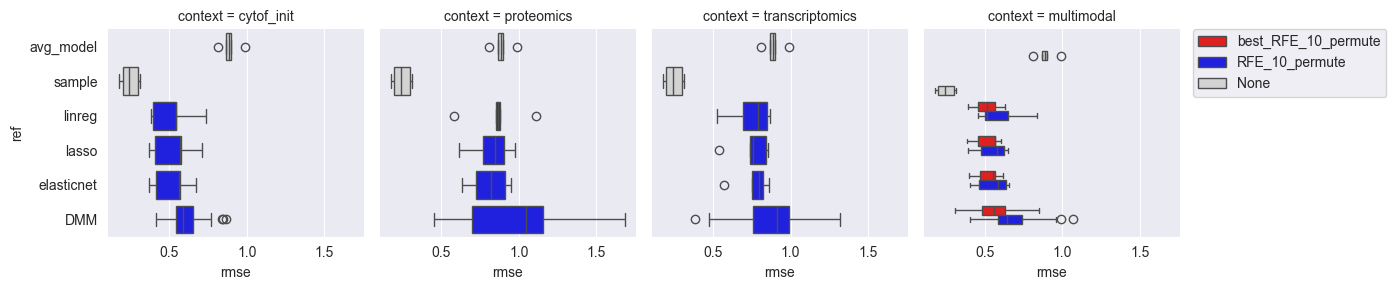

In [3]:
palette = {
    "RFE_10_permute": "blue",
    "HVGRFE_10_permute": "blue",
    "best_RFE_10_permute": "red",
    "None": "lightgray"
}

g = sns.FacetGrid(
    val_df_usual_samples,
    col="context",
    col_order=["cytof_init", "proteomics", "transcriptomics", "multimodal"]
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "linreg", "lasso", "elasticnet", "DMM"],
    hue="features",
    palette=palette
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# Added MDA-MB-468 (EGFR overexpression)

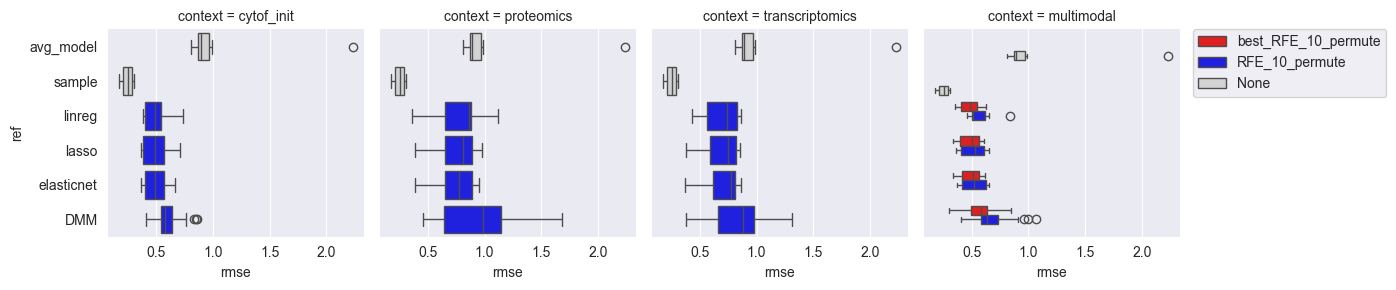

In [4]:
palette = {
    "RFE_10_permute": "blue",
    "HVGRFE_10_permute": "blue",
    "best_RFE_10_permute": "red",
    "None": "lightgray"
}

g = sns.FacetGrid(
    val_df,
    col="context",
    col_order=["cytof_init", "proteomics", "transcriptomics", "multimodal"]
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "linreg", "lasso", "elasticnet", "DMM"],
    hue="features",
    palette=palette
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# As best_RFE_10_permute outperforms RFE_10_permute for multimodal, we can subset to that feature selection strategy only and rather look at sample split

In [5]:
val_df = val_df[~((val_df["context"] == "multimodal") &
                  (val_df["features"] == "RFE_10_permute"))]
val_df_usual_samples = val_df[val_df.samples.isin(["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"])]

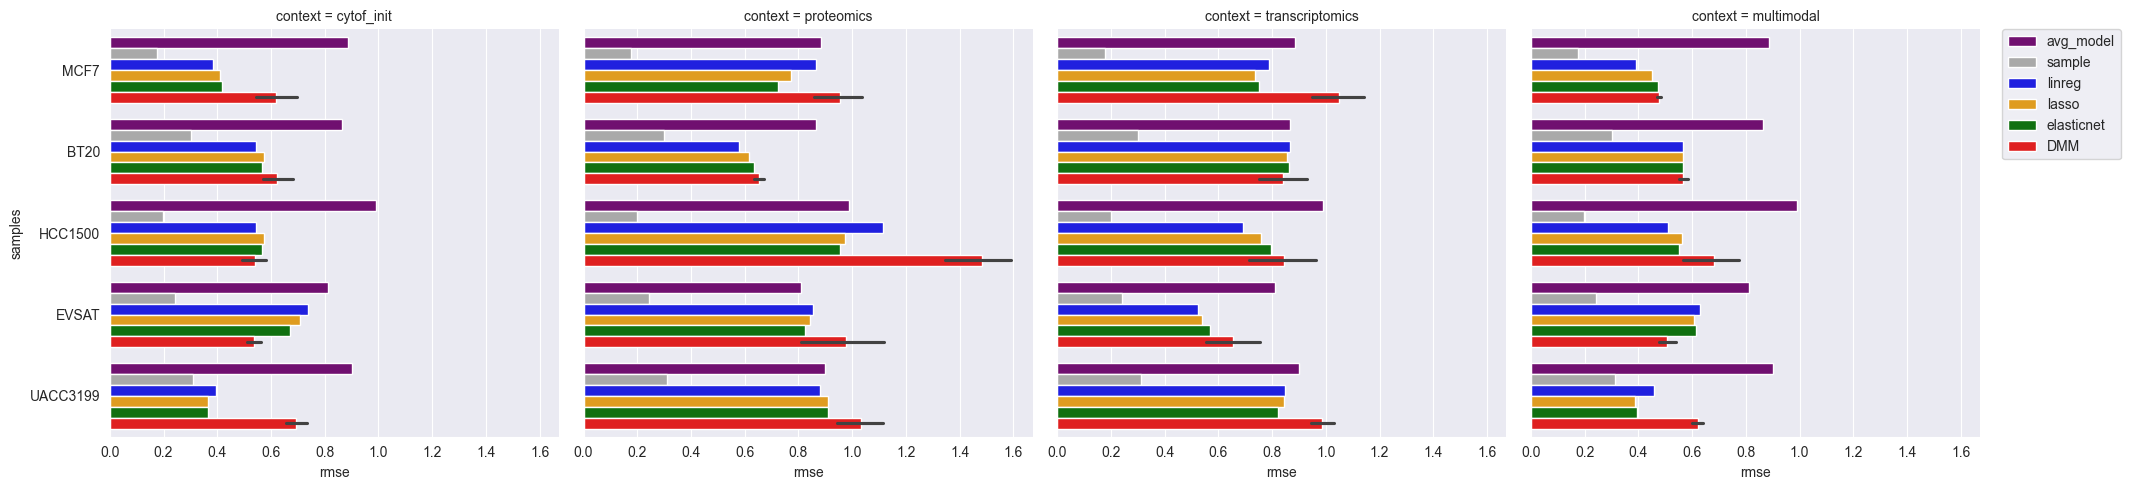

In [6]:
ref_palette = {
    "avg_model": "purple",
    "sample": "darkgray",
    "linreg": "blue",
    "lasso": "orange",
    "elasticnet": "green",
    "DMM": "red"
}
g = sns.FacetGrid(
    val_df_usual_samples,
    col="context",
    col_order=["cytof_init", "proteomics", "transcriptomics", "multimodal"],
    height=5,
)

g.map_dataframe(
    sns.barplot,
    y="samples",
    x="rmse",
    hue="ref",
    order=["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"],
    palette=ref_palette,
    hue_order=["avg_model", "sample", "linreg", "lasso", "elasticnet", "DMM"]
)
# plt.xlim([0, 2.5])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# As we already knew, we are doing a pretty horrible job (particularly with proteomics on HCC1500!), but in particular cytof_init is getting beaten by regressors on BT-20 and UACC-3199. multimodal seems to save BT-20, while it does not manage to improve much on UACC_3199...

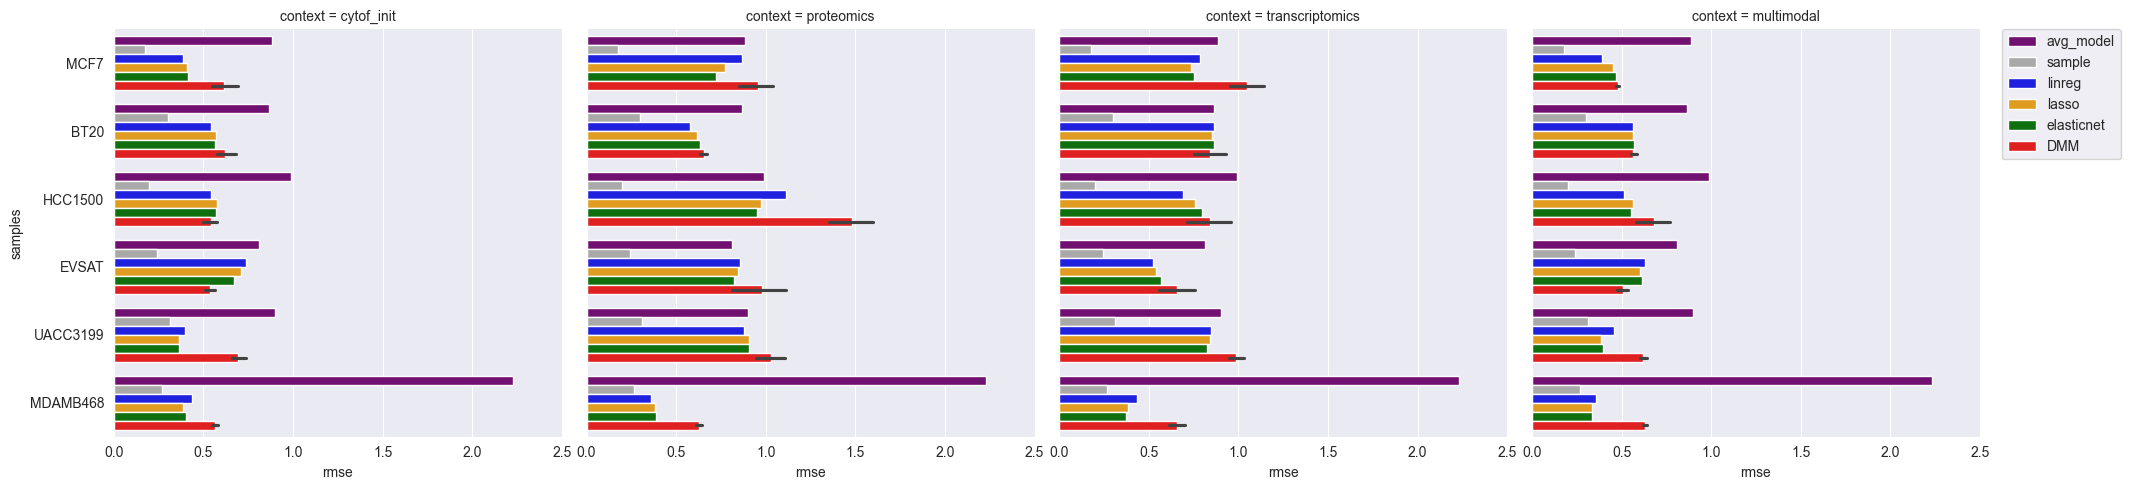

In [7]:
ref_palette = {
    "avg_model": "purple",
    "sample": "darkgray",
    "linreg": "blue",
    "lasso": "orange",
    "elasticnet": "green",
    "DMM": "red"
}
g = sns.FacetGrid(
    val_df,
    col="context",
    col_order=["cytof_init", "proteomics", "transcriptomics", "multimodal"],
    height=5,
)

g.map_dataframe(
    sns.barplot,
    y="samples",
    x="rmse",
    hue="ref",
    order=["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199", "MDAMB468"],
    palette=ref_palette,
    hue_order=["avg_model", "sample", "linreg", "lasso", "elasticnet", "DMM"]
)
plt.xlim([0, 2.5])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# Looks like MDA-MB-468 is pretty easy for regressors, not the easiest but not even the hardest for DMMs, but incredibly hard for the avg_model (exceeds 2.0) - is this because of super high EGFR levels?